# Ts3 - simulacion de un ADC (cuantizador)

Simulo un cuantizador de B bits sobre una senoidal de potencia unitaria y veo como cambia la señal segun el ancho de palabra B.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# la reuso de la TS1, no tiene sentido reescribirla
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    tt = np.arange(nn) / fs
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt.reshape(nn, 1), xx.reshape(nn, 1)

In [2]:
# el cuantizador en si
def cuantizar(xn, B, vref):
    # paso de cuantizacion: el rango total partido en 2^B escalones
    q = vref / 2**B

    # redondeo al escalon mas cercano (no lo trunco), asi el error de
    # cuantizacion queda centrado en 0 y acotado entre -q/2 y q/2
    xn_q = q * np.round(xn / q)

    # si xn se va justo al borde del rango, el redondeo puede tirarlo un
    # escalon afuera -> lo recorte asi no se pasa de +-vref/2
    xn_q = np.clip(xn_q, -vref / 2, vref / 2 - q)

    return xn_q, q

In [3]:
# señal de entrada: senoidal de potencia unitaria
N = 1000
fs = 1000
ff = 1  # frecuencia arbitraria, no me afecta el analisis de cuantizacion

# para que la potencia normalizada de la senoidal sea 1, Amp tiene que ser
# raiz(2), porque la potencia media de un seno es Amp^2/2
amp = np.sqrt(2)

tt, xx = mi_funcion_sen(amp, 0, ff, 0, N, fs)

# el Vref del ADC tiene que cubrir toda la excursion de la señal, sino
# se satura (clipea) y el error de cuantizacion deja de tener sentido.
# use  el rango justo (pico a pico) para aprovechar toda la escala
vref = 2 * amp
bits = [4, 8, 16]

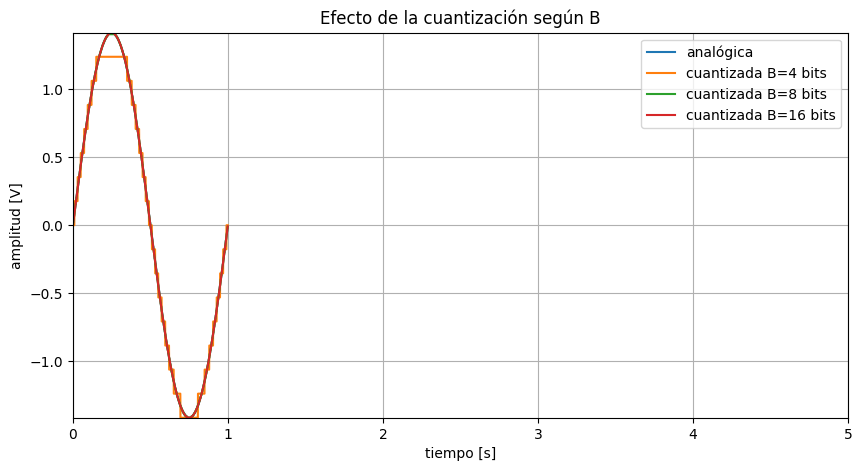

In [4]:
# grafico: analogica vs cuantizada, mismo rango de Volts
plt.figure(figsize=(10, 5))
plt.plot(tt, xx, label="analógica", linewidth=1.5)

for B in bits:
    xq, q = cuantizar(xx, B, vref)
    plt.plot(tt, xq, label=f"cuantizada B={B} bits")

# me quedo con pocos ciclos, sino no se ve bien el escalonado
plt.xlim(0, 5 / ff)
plt.ylim(-vref / 2, vref / 2)
plt.xlabel("tiempo [s]")
plt.ylabel("amplitud [V]")
plt.title("Efecto de la cuantización según B")
plt.legend()
plt.grid(True)
plt.show()

B=4 bits | q=0.17678 V
  media medida: 0.019976  (teorica: 0)
  varianza medida: 0.004342  (teorica: 0.002604)
  correlacion señal-error: 0.3478


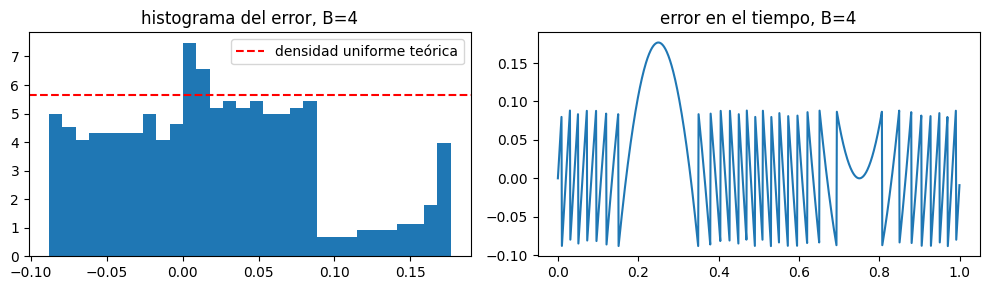

B=8 bits | q=0.01105 V
  media medida: 0.000320  (teorica: 0)
  varianza medida: 0.000012  (teorica: 0.000010)
  correlacion señal-error: 0.1024


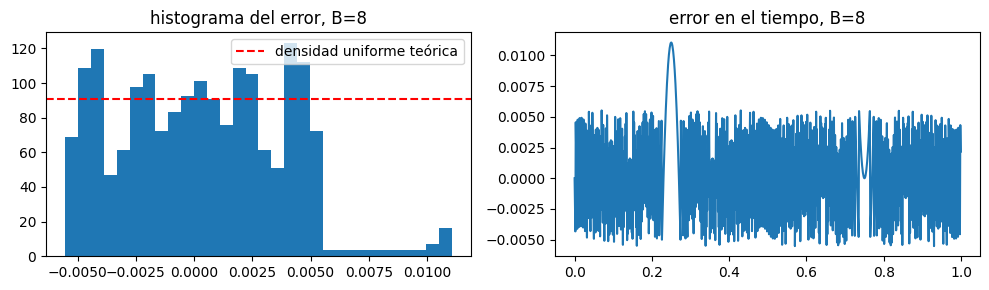

B=16 bits | q=0.00004 V
  media medida: 0.000000  (teorica: 0)
  varianza medida: 0.000000  (teorica: 0.000000)
  correlacion señal-error: 0.0175


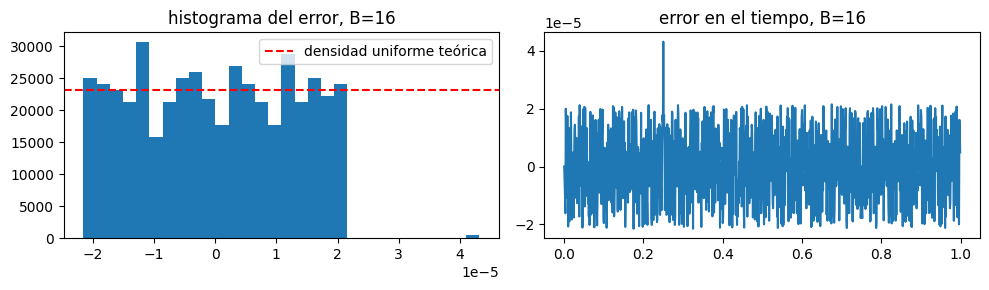

In [5]:
# BONUS: caracterizar el error de cuantizacion
# en teoria el error deberia ser ruido uniforme entre -q/2 y q/2, con
# media 0, varianza q^2/12 y sin correlacion con la señal original
for B in bits:
    xq, q = cuantizar(xx, B, vref)
    error = xx - xq

    media = error.mean()
    varianza = error.var()
    var_teorica = q**2 / 12
    corr = np.corrcoef(xx.flatten(), error.flatten())[0, 1]

    print(f"B={B} bits | q={q:.5f} V")
    print(f"  media medida: {media:.6f}  (teorica: 0)")
    print(f"  varianza medida: {varianza:.6f}  (teorica: {var_teorica:.6f})")
    print(f"  correlacion señal-error: {corr:.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].hist(error, bins=30, density=True)
    ax[0].axhline(1 / q, color="r", linestyle="--", label="densidad uniforme teórica")
    ax[0].set_title(f"histograma del error, B={B}")
    ax[0].legend()

    ax[1].plot(tt, error)
    ax[1].set_title(f"error en el tiempo, B={B}")
    plt.tight_layout()
    plt.show()

# nota: con pocos bits (B=4) la señal es una senoidal pura y periodica,
# entonces el error termino siendo bastante predecible/correlacionado con
# xx en vez de parecerse a ruido blanco. el modelo de ruido uniforme
# es una aproximacion que se cumple mejor cuanto mas bits
# tenemos (B=16) o cuando la señal es mas "movida" (ruidosa, no periodica)